In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

df = pd.read_csv("loan_applications.csv")

# Basic Overview

In [2]:
print(df['actual_outcome'].value_counts(normalize=True).round(3))
print(f"\nNull documented income: {df['documented_monthly_income'].isna().sum()}")

actual_outcome
repaid       0.646
defaulted    0.272
ongoing      0.082
Name: proportion, dtype: float64

Null documented income: 283


# Income misrepresentation flag

In [3]:
df['income_ratio'] = df['documented_monthly_income'] / df['stated_monthly_income']
print(f"\nLikely misrepresentation (ratio < 0.5): {(df['income_ratio'] < 0.5).sum()}")


Likely misrepresentation (ratio < 0.5): 85


# Plot: Default rate by employment status

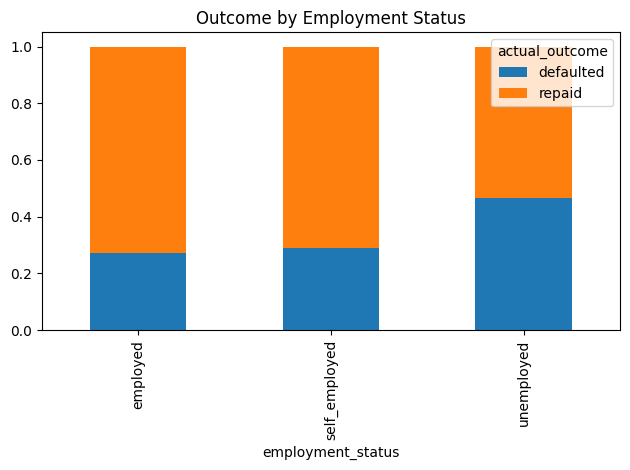

In [4]:
outcome_by_emp = df[df['actual_outcome'] != 'ongoing'].groupby('employment_status')['actual_outcome'].value_counts(normalize=True).unstack()
outcome_by_emp.plot(kind='bar', stacked=True)
plt.title('Outcome by Employment Status')
plt.tight_layout()
plt.savefig('plot_employment_outcomes.png')
plt.show()

# Plot: Rule score distribution by actual outcome

We check if the rule-based system leads to a good separation of distributions between defaulted and repaid. 

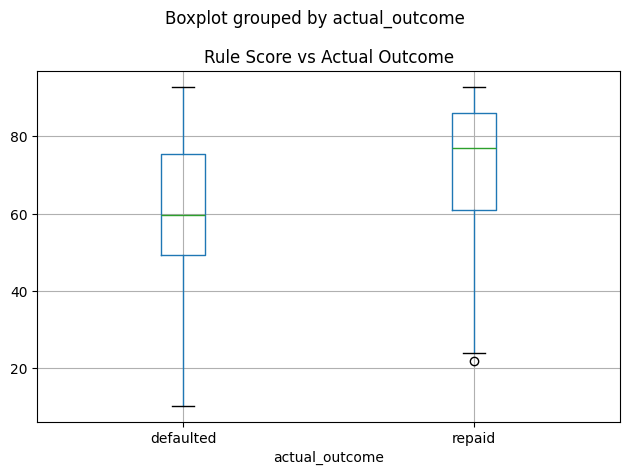

In [5]:
df[df['actual_outcome'] != 'ongoing'].boxplot(column='rule_based_score', by='actual_outcome')
plt.title('Rule Score vs Actual Outcome')
plt.tight_layout()
plt.savefig('plot_score_distribution.png')
plt.show()

## Observation: Employment Status Bias
Default rates are nearly identical: employed ~26%, self-employed ~29%, a difference of ~3 percentage points. Yet the rule-based system scores employe at 100 vs self-employed at 60 (a 40-point penalty, weighted at 15%). This is the core fairness problem we need to investigate: the penalty is disproportionate to the actual risk difference

## Observation: Rule Score Separation
The rule score shows moderate separation by median (~60 defaulted vs ~78 repaid) but the interquartile ranges overlap substantially. A threshold at 75 will misclassify many defaulters who scores in the 60-80 range. This is exactly the gap a learned model should exploit.

Among resolved applications (excluding ongoing), default rate is 27.2%, higher than the raw 14% because ongoing apps are disproportionately recent/lower-risk. Excluding them slightly inflates our apparent default rate.

# Feature Engineering
We exclude ongoing applications. No outcome means we can't train on them.
This introduces survivorship bias: ongoing apps may be more recent or lower risk, so our training set slightly overrepresents resolved (and riskier) cases.

In [6]:
# Work on a copy, exclude ongoing
df_model = df[df['actual_outcome'] != 'ongoing'].copy()
df_model['target'] = (df_model['actual_outcome'] == 'defaulted').astype(int)

## Income verification 
Two signals: did they submit docs at all, and do the numbers match?

In [ ]:
df_model['has_docs'] = df_model['documented_monthly_income'].notna().astype(int)
df_model['income_ratio'] = (
    df_model['documented_monthly_income'] / df_model['stated_monthly_income']
)
# Missing docs -> fill with 0, not the mean.
# Mean imputation would imply average trustworthiness for undocumented applicants.
# 0 treats missing docs as a risk signal, which matches domain logic.
df_model['income_ratio'] = df_model['income_ratio'].fillna(0)
df_model['likely_misrepresentation'] = (df_model['income_ratio'] < 0.5).astype(int)

## Loan affordability
How large is the loan relative to what they earn? Higher = more stress.

In [8]:
df_model['loan_to_income_ratio'] = (
    df_model['loan_amount'] / df_model['stated_monthly_income']
)

## Cash flow stress
What fraction of deposits are they spending? Close to 1.0 = living on the edge.

In [9]:
df_model['withdrawal_rate'] = (
    df_model['monthly_withdrawals'] / df_model['monthly_deposits'].clip(lower=1)
)

## Account stability
Keeping these three (positive ending balance, no overdrafts, consistent deposits) as separate features rather than combining them into a composite score. Combining would include the rule-based system's weights. We want the model to learn its own weights from the data.

In [ ]:
df_model['balance_low'] = (df_model['bank_ending_balance'] < 500).astype(int)
# bank_has_overdrafts and bank_has_consistent_deposits stay as raw columns

## Employment status
Keeping all three dummies (no drop_first) so SHAP values show each group's contribution explicitly. Important for fairness analysis.

In [ ]:
df_model = pd.get_dummies(df_model, columns=['employment_status'], drop_first=False)

## Final feature list 
rule_based_score is intentionally excluded. Including it would make the model a meta-learner on the baseline rather than learning from raw signals directly.

In [12]:
features = [
    'stated_monthly_income',
    'loan_amount',
    'loan_to_income_ratio',
    'income_ratio',
    'has_docs',
    'likely_misrepresentation',
    'bank_ending_balance',
    'balance_low',
    'bank_has_overdrafts',
    'bank_has_consistent_deposits',
    'monthly_withdrawals',
    'monthly_deposits',
    'withdrawal_rate',
    'num_documents_submitted',
    'employment_status_employed',
    'employment_status_self_employed',
    'employment_status_unemployed'
]

X = df_model[features]
y = df_model['target']

print(f"Feature matrix shape: {X.shape}")
print(f"Default rate in training set: {y.mean():.3f}")
print(f"\nAny nulls remaining?\n{X.isnull().sum()[X.isnull().sum() > 0]}")

Feature matrix shape: (1836, 17)
Default rate in training set: 0.297

Any nulls remaining?
Series([], dtype: int64)


29.7% default rate in our training set (resolved applications only).

Raw dataset was ~14% but excluding ongoing inflates this. Ongoing apps are disproportionately recent/lower-risk.

We'll use scale_pos_weight in XGBoost to handle remaining imbalance.

scale_pos_weight = (1 - 0.297) / 0.297 approx 2.37. 

# Training

In [ ]:
from xgboost import XGBClassifier